<a href="https://colab.research.google.com/github/dustu15/AI-build-Training/blob/trainingday/transformer_image_to_text_day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import transformers
print(transformers.__version__)

4.57.6


In [5]:
!pip index versions transformers

transformers (5.2.0)
Available versions: 5.2.0, 5.1.0, 5.0.0, 4.57.6, 4.57.5, 4.57.4, 4.57.3, 4.57.2, 4.57.1, 4.56.2, 4.56.1, 4.56.0, 4.55.4, 4.55.3, 4.55.2, 4.55.1, 4.55.0, 4.54.1, 4.54.0, 4.53.3, 4.53.2, 4.53.1, 4.53.0, 4.52.4, 4.52.3, 4.52.2, 4.52.1, 4.51.3, 4.51.2, 4.51.1, 4.51.0, 4.50.3, 4.50.2, 4.50.1, 4.50.0, 4.49.0, 4.48.3, 4.48.2, 4.48.1, 4.48.0, 4.47.1, 4.47.0, 4.46.3, 4.46.2, 4.46.1, 4.45.2, 4.45.1, 4.45.0, 4.44.2, 4.44.1, 4.44.0, 4.43.4, 4.43.3, 4.43.2, 4.43.1, 4.43.0, 4.42.4, 4.42.3, 4.42.2, 4.42.1, 4.42.0, 4.41.2, 4.41.1, 4.41.0, 4.40.2, 4.40.1, 4.40.0, 4.39.3, 4.39.2, 4.39.1, 4.39.0, 4.38.2, 4.38.1, 4.38.0, 4.37.2, 4.37.1, 4.37.0, 4.36.2, 4.36.1, 4.36.0, 4.35.2, 4.35.1, 4.35.0, 4.34.1, 4.34.0, 4.33.3, 4.33.2, 4.33.1, 4.33.0, 4.32.1, 4.32.0, 4.31.0, 4.30.2, 4.30.1, 4.30.0, 4.29.2, 4.29.1, 4.29.0, 4.28.1, 4.28.0, 4.27.4, 4.27.3, 4.27.2, 4.27.1, 4.27.0, 4.26.1, 4.26.0, 4.25.1, 4.24.0, 4.23.1, 4.23.0, 4.22.2, 4.22.1, 4.22.0, 4.21.3, 4.21.2, 4.21.1, 4.21.0, 4.20.1, 4.20.0, 4.

In [14]:
!pip install transformers==4.57.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [1]:
from transformers import pipeline

pipe = pipeline("image-to-text", model="Salesforce/blip-image-captioning-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor di

[{'generated_text': 'a small blue and yellow frog sitting on a leaf'}]

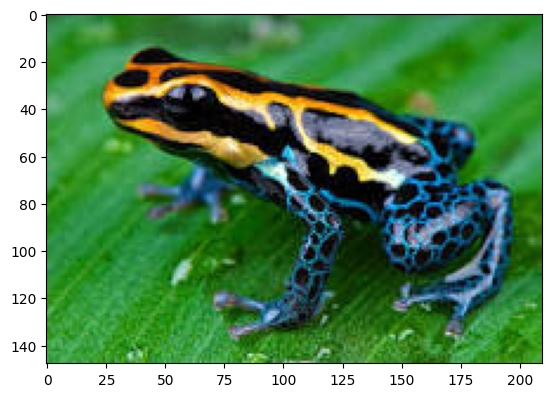

In [12]:
from PIL import Image
import matplotlib.pyplot as plt
image2 = Image.open("/content/fr1.jpeg")
plt.imshow(image2)

pipe(image2)

[{'generated_text': 'a jet flying in the sky'}]

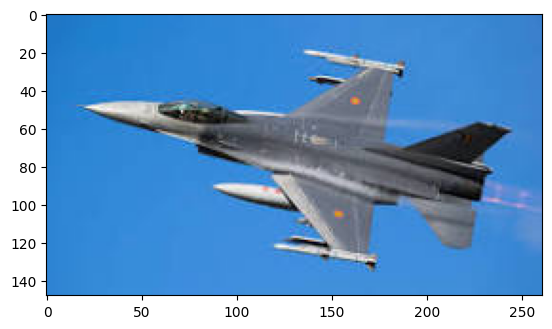

In [14]:
image2 = Image.open("/content/f1.jpeg")
plt.imshow(image2)

pipe(image2)

In [15]:
!pip install gradio

In [16]:
import gradio as gr

def image_captioning(image):
    # The pipe expects a list of dictionaries with 'image' and 'text'
    # Since we are doing general captioning, we'll provide a general question or no question.
    # Based on previous successful executions, passing a PIL Image directly works here.
    results = pipe(image)
    # The pipeline returns a list of dictionaries, e.g., [{'generated_text': '...'}]
    return results[0]['generated_text']

# Create the Gradio interface
interface = gr.Interface(
    fn=image_captioning,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Image Captioning with BLIP",
    description="Upload an image and get a descriptive caption generated by the Salesforce BLIP model."
)

# Launch the interface
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://30ec84e4641c62a8f2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
